In [1]:
import torch
from main.model import get_model

In [2]:
checkpoint_path = '/home/jupyter-nafisha/X-ray/checkpoints/last_model.pth'
# device = "cuda" if torch.cuda.is_available() else "cpu"
device= "cpu"

In [3]:
model= get_model()
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [4]:
from torchvision import transforms

def get_val_transform():
    return transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485]*3, std=[0.229]*3)
    ])

In [5]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor):
        self.model.zero_grad()

        logits = self.model(input_tensor)
        score = logits.squeeze()     # binary logit

        score.backward()

        # Grad-CAM computation
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode="bilinear", align_corners=False)

        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam


In [260]:
from PIL import Image

# TN
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/c40efde4da3c59ef506a9138b5fb3f5f.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/75343f262204d784857b6b675a923cd7.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/3e0e43fa2de366a0ac10e036f92a888d.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/924e69559651654e67727eb1d8ca1b7a.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/37a162a49494e70202afdd543efe7457.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/74ea7c95d4910affdaa09dc2d06edac4.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/7fcc22d964a500fdf1b82a9bea30c301.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/fbb03bc06ead448a618f9040b1932196.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/62cd251361d7cb1d9a713c2508f0b4d7.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/74bfbb54c819c289ee1245eb003e16c4.png'

# FN
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/0f27846dfa86e51c27db5fe4ea5a52ad.png'     # Aortic enlargement
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/30732ad387fb4f2429a6c5b965910869.png'     # Pulmonary fibrosis
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/3116e8acc9b97d7a581ea891ae9bed80.png'     # Aortic enlargement, Pleural thickening
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/bb8f70bb23d06edce7b87df6f529d0b4.png'     # ILD, Infiltration, Lung Opacity, Pleural thickening, Pulmonary fibrosis
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/b06c6e447980a2561175026ad10ae04d.png'     # Aortic enlargement, Cardiomegaly, Lung Opacity, Nodule/Mass
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/b37cd57257591d19366e5a6f23ceb8f6.png'     # Aortic enlargement, Calcification, Lung Opacity, Other lesion
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/9c314e403d3e6e3ed09e79a57019f9ad.png'     # Calcification, ILD
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/9df823bdb8130ffcea2bee7544a0db94.png'     # ILD, Other lesion, Pulmonary fibrosis
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/a6dc083013ac8108bd13fbac28921290.png'     # Aortic enlargement
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/d1bb581de986967b12d4ee6a064d70e8.png'     # Pulmonary fibrosis

# FP
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/fc6398e834598afce4e644237b1666ad.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/633732084de1dcecb1aaa0dfce84b896.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/548bf08ac3fb4268aec314b42911af13.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/15703baf49cdef5b522570cff4324808.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/dc5aaa675e13f5a08673dd0ad0d80d71.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/5198fc942534fe6e2c60119e3a22dd8a.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/3e288b491b9c0fe5e4dcdd1aeb86ecc8.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/9687cf83172b86be54e97b5d26f19c20.png'
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/a4f53850cb70bbfa9f3ea93f0117a9c1.png'
image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/5a7675d92d86f8fc779d44d82205e51f.png'


# TP
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/31ffa866e091965da25a408b4cc7d0db.png'     # Lung Opacity, Pleural effusion, Pneumothorax
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/04923676c5e29c25966fbd07fa12e2e8.png'     # Aortic enlargement, Cardiomegaly, Pleural thickening
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/ed696103132aee457b0e11ce0d7b7d27.png'     # ILD, Infiltration, Lung Opacity, Pleural effusion
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/5450f21b06e8ee3fcdc1375711bc28ee.png'     # Lung Opacity, Pleural effusion
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/256b0ad89e73b03f15635e647c2bdb02.png'     # Pleural thickening, Pulmonary fibrosis
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/58f1092e67574175f2f17b06b1f66911.png'     # Nodule/Mass, Pulmonary fibrosis
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/8de2c306ed9fa7c44c70d249af346d9b.png'     # Infiltration, Lung Opacity, Pulmonary fibrosis
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/8098d1ce056318c03a3c70ccf3707945.png'     # Atelectasis, Lung Opacity, Pleural effusion, Pleural thickening, Pulmonary fibrosis
# image_path = '/home/jupyter-nafisha/X-ray/Inference_data/Orig_VinBig_TestData/31ffa866e091965da25a408b4cc7d0db.png'     # Lung Opacity, Pleural effusion, Pneumothorax

transform = get_val_transform()
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(image_tensor)                 
    prob = torch.sigmoid(logits).item()  
    pred = 1 if prob > 0.5 else 0
    
label_map = {0: "Normal", 1: "Abnormal"}
result = label_map[pred]

print(prob, result)

target_layer = model.features.denseblock4
gradcam = GradCAM(model, target_layer)
cam = gradcam.generate(image_tensor)

orig = np.array(image.resize((224, 224)))
heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
overlay = np.uint8(0.6 * orig + 0.4 * heatmap)


0.9999868869781494 Abnormal


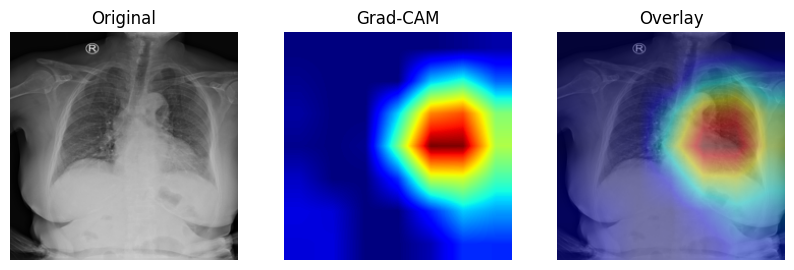

In [261]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(orig)
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Grad-CAM")
plt.imshow(cam, cmap="jet")
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis("off")

plt.show()


## using camtum

In [239]:
from captum.attr import LayerGradCam

transform = get_val_transform()
image = Image.open(image_path).convert("RGB")
image_tensor = transform(image).unsqueeze(0).to(device)

# Choose final conv layer in DenseNet201 (last layer in last dense block)
target_layer = model.features.denseblock4
gradcam = LayerGradCam(model, target_layer)

# Get Grad-CAM attribution for regression output
attribution = gradcam.attribute(image_tensor, target=0)
attr_map = attribution.squeeze().detach().cpu().numpy()

In [240]:
attr_map = np.maximum(attr_map, 0)  # ReLU (important)
attr_map = attr_map / (attr_map.max() + 1e-8)

# Resize to model input size (224x224)
heatmap = cv2.resize(attr_map, (224, 224))

# Convert tensor to numpy
img_np = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()

# Undo normalization (ImageNet)
mean = np.array([0.485, 0.485, 0.485])
std = np.array([0.229, 0.229, 0.229])
img_np = (img_np * std) + mean
img_np = np.clip(img_np, 0, 1)


heatmap_color = cv2.applyColorMap(
    np.uint8(255 * heatmap),
    cv2.COLORMAP_JET
)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
heatmap_color = heatmap_color / 255.0


overlay = 0.6 * img_np + 0.4 * heatmap_color
overlay = np.clip(overlay, 0, 1)


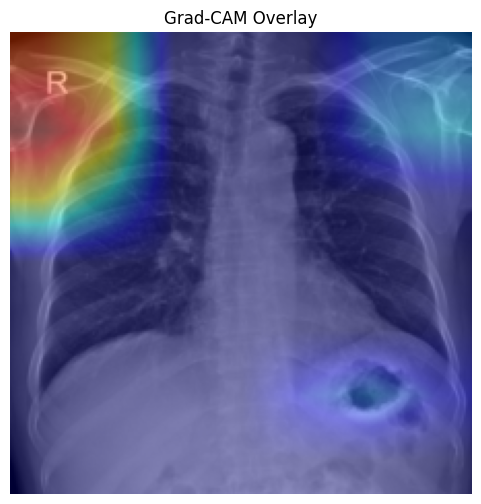

In [241]:
plt.figure(figsize=(6,6))
plt.imshow(overlay)
plt.axis("off")
plt.title("Grad-CAM Overlay")
plt.show()
